In [1]:
import imageio
from skimage.morphology import dilation, remove_small_objects, area_closing, area_opening, erosion, disk
from skimage.filters import median, threshold_local, rank, threshold_otsu
from skimage import restoration
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import vigra

In [2]:
import torch
import torch.nn as nn

class NNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(NNet, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Mid-level
        self.mid_level = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(192, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, out_channels, kernel_size=2, stride=2, output_padding=0)  # Adjusted output_padding
        )

    def forward(self, x):
        # Encoder
        x1 = self.encoder(x)

        # Mid-level
        x2 = self.mid_level(x1)

        # Decoder
        x3 = self.decoder(x2)

        return x3

# Example usage:
in_channels = 1
out_channels = 3  

# Adjust the model instantiation
model = NNet(in_channels, out_channels)
# model.load_state_dict(torch.load('unet_model.pth'))

In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from scipy.ndimage import distance_transform_edt

class ERDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)

    def __len__(self):
        return sum(len(os.listdir(os.path.join(self.root_dir, cls, 'images'))) for cls in self.classes)

    def __getitem__(self, idx):
        current_class_idx = 0
        while idx >= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images'))):
            idx -= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images')))
            current_class_idx += 1

        current_class = self.classes[current_class_idx]
        img_folder = os.path.join(self.root_dir, current_class, 'images')
        mask_folder = os.path.join(self.root_dir, current_class, 'skel')

        img_name = os.listdir(img_folder)[idx]
        img_path = os.path.join(img_folder, img_name)
        mask_name = os.path.splitext(img_name)[0].split('_')[0] + '_proc_skel.png'  # Assuming mask files have the same name as images with '_mask' appended
        mask_path = os.path.join(mask_folder, mask_name)

#         image = Image.open(img_path)#.convert("RGB")
        image = imageio.imread(img_path)
#         mask = Image.open(mask_path)#.convert("L")  # Convert to grayscale mask
        mask = imageio.imread(mask_path)
#         mask = distance_transform_edt(np.invert(mask))
        edt = vigra.filters.distanceTransform2D(mask.astype(np.float32))
        vec_edt = vigra.filters.vectorDistanceTransform(mask.astype(np.float32))
#         vec_edt = vec_edt.transpose(2, 0, 1)
        edt = np.expand_dims(edt, axis=2)
        mask = np.concatenate((edt, vec_edt), axis=2)
#         mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

# Define your transformation
transform = transforms.Compose([
#     transforms.Resize((128, 128)),
    transforms.ToTensor(),
#     transforms.Normalize(0, 1)
])

# Define your dataset
# root_dir = 'path/to/your/dataset'
root_dir = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/'

dataset = ERDataset(root_dir, transform=transform)

# Define your dataloader
# batch_size = 4
# data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/io/image.py:11: UserWarning: Failed to load image Python extension: /local-scratch/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/torchvision/image.so: undefined symbol: _ZNK3c1010TensorImpl36is_contiguous_nondefault_policy_implENS_12MemoryFormatE
  warn(f"Failed to load image Python extension: {e}")


In [4]:
dl = DataLoader(dataset, batch_size=4, shuffle=True)

# for i, (img, mask) in enumerate(dl):
#     print(img.shape)
#     print(mask.shape)
#     plt.imshow(mask[0][0])

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms


from torchmetrics.classification import BinaryJaccardIndex

seed_val = 674

torch.manual_seed(seed_val)
torch.cuda.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.enabled=False
torch.backends.cudnn.benchmark = False


in_channels = 1
out_channels = 3
model = NNet(in_channels, out_channels)

# Define loss function and optimizer
# criterion = nn.BCEWithLogitsLoss()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define dataset and dataloaders
# root_dir = 'path/to/your/dataset'
# transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
# ])

# Assuming an 80-20 train-test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training loop
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    for inputs, masks in train_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
#         outputs = (torch.sigmoid(outputs) > 0.5).float()
        loss = criterion(outputs, masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the training loss for each epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item()}")

# Testing loop
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, masks in test_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, masks)
        test_loss += loss.item()

# Calculate and print the average test loss
average_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {average_test_loss}")

# Save the trained model
torch.save(model.state_dict(), 'unet_model_vec_edt.pth')


Epoch [1/100], Training Loss: 18.147993087768555
Epoch [2/100], Training Loss: 18.654748916625977
Epoch [3/100], Training Loss: 20.244548797607422
Epoch [4/100], Training Loss: 24.078929901123047
Epoch [5/100], Training Loss: 31.797277450561523
Epoch [6/100], Training Loss: 138.86282348632812
Epoch [7/100], Training Loss: 87.6646957397461
Epoch [8/100], Training Loss: 13.78797721862793
Epoch [9/100], Training Loss: 8.314697265625
Epoch [10/100], Training Loss: 17.223468780517578
Epoch [11/100], Training Loss: 9.503617286682129
Epoch [12/100], Training Loss: 5.701377868652344
Epoch [13/100], Training Loss: 9.029261589050293
Epoch [14/100], Training Loss: 8.194206237792969
Epoch [15/100], Training Loss: 4.543326377868652
Epoch [16/100], Training Loss: 9.473188400268555
Epoch [17/100], Training Loss: 8.9511137008667
Epoch [18/100], Training Loss: 114.31179809570312
Epoch [19/100], Training Loss: 65.552490234375
Epoch [20/100], Training Loss: 11.559087753295898
Epoch [21/100], Training Los

In [6]:
from skimage import restoration
import copy
from skimage.filters import threshold_otsu

imgpath = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/images/rtn22_er_mean.png'

image = Image.open(imgpath)
transform = transforms.Compose([
    transforms.ToTensor(),
])

image = transform(image)
image = image.unsqueeze(0)  # Add batch dimension

# Forward pass through the model
model.eval()
with torch.no_grad():
    output = model(image.cuda())

# Convert the output to probabilities by applying the sigmoid activation
output_probs = torch.sigmoid(output)

# Convert tensors to numpy arrays for visualization
image_np = image.squeeze().numpy()
output_probs_np = output_probs.cpu().squeeze().numpy()

norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())


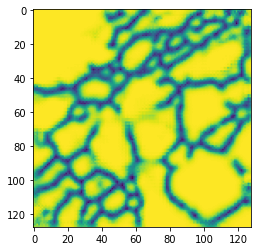

In [8]:
plt.imshow(norm[0])

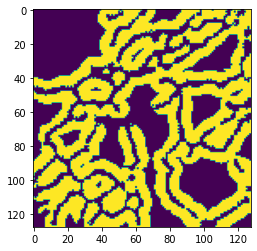

In [7]:
rb = restoration.rolling_ball(norm[0])
subt = norm[0] - rb

thr = threshold_otsu(subt)

subt2 = copy.deepcopy(subt)

subt2[subt < thr] = 0.
subt2[subt >= thr] = 255.

import matplotlib.pyplot as plt
plt.imshow(subt2)